In [1]:
pip install pyspark

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Module 1 — Data Loading & Schema Handling

In [2]:
import pyspark
from pyspark.sql import SparkSession

In [3]:
spark = SparkSession.builder.appName("PySparkExample").getOrCreate()

## Task 1: Load all CSV files into PySpark DataFrames

In [4]:
full_grouped_path = "data/full_grouped.csv"
covid_clean_path = "data/covid_19_clean_complete.csv"
country_latest_path = "data/country_wise_latest.csv"
day_wise_path = "data/day_wise.csv"
usa_county_path = "data/usa_county_wise.csv"
worldometer_path = "data/worldometer_data.csv"

In [5]:
full_grouped_df = spark.read.csv(
    full_grouped_path,
    header=True,
    inferSchema=True
)
covid_clean_df = spark.read.csv(
    covid_clean_path,
    header=True,
    inferSchema=True
)
country_latest_df = spark.read.csv(
    country_latest_path,
    header=True,
    inferSchema=True
)
day_wise_df = spark.read.csv(
    day_wise_path,
    header=True,
    inferSchema=True
)
usa_county_df = spark.read.csv(
    usa_county_path,
    header=True,
    inferSchema=True
)
worldometer_df = spark.read.csv(
    worldometer_path,
    header=True,
    inferSchema=True
)
full_grouped_df.printSchema()
covid_clean_df.printSchema()
country_latest_df.printSchema()
day_wise_df.printSchema()
usa_county_df.printSchema()
worldometer_df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true

In [6]:
print(full_grouped_df.count())
print(covid_clean_df.count())
print(country_latest_df.count())
print(day_wise_df.count())
print(usa_county_df.count())
print(worldometer_df.count())

35156
49068
187
188
627920
209


In [7]:
full_grouped_df.show(5)

+----------+--------------+---------+------+---------+------+---------+----------+-------------+--------------------+
|      Date|Country/Region|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|          WHO Region|
+----------+--------------+---------+------+---------+------+---------+----------+-------------+--------------------+
|2020-01-22|   Afghanistan|        0|     0|        0|     0|        0|         0|            0|Eastern Mediterra...|
|2020-01-22|       Albania|        0|     0|        0|     0|        0|         0|            0|              Europe|
|2020-01-22|       Algeria|        0|     0|        0|     0|        0|         0|            0|              Africa|
|2020-01-22|       Andorra|        0|     0|        0|     0|        0|         0|            0|              Europe|
|2020-01-22|        Angola|        0|     0|        0|     0|        0|         0|            0|              Africa|
+----------+--------------+---------+------+---------+--

# Module 2: Data Cleaning Tasks


## Task 2: Handle Missing Province/State Values


In [8]:
covid_clean_df.columns

['Province/State',
 'Country/Region',
 'Lat',
 'Long',
 'Date',
 'Confirmed',
 'Deaths',
 'Recovered',
 'Active',
 'WHO Region']

In [9]:
from pyspark.sql.functions import col

covid_clean_df = covid_clean_df \
    .withColumnRenamed("Province/State", "Province_State") \
    .withColumnRenamed("Country/Region", "Country_Region")

covid_clean_df = covid_clean_df.fillna({
    "Province_State": "Unknown"
})

covid_clean_df.filter(
    col("Province_State").isNull()
).count()

0

In [10]:
null_province_df = covid_clean_df.filter(
    col("Province_State").isNull()
)
null_province_df.count()
null_province_df.show(10)

+--------------+--------------+---+----+----+---------+------+---------+------+----------+
|Province_State|Country_Region|Lat|Long|Date|Confirmed|Deaths|Recovered|Active|WHO Region|
+--------------+--------------+---+----+----+---------+------+---------+------+----------+
+--------------+--------------+---+----+----+---------+------+---------+------+----------+



Country-wise Null Count Report

In [11]:
country_null_report = covid_clean_df \
    .filter(col("Province_State").isNull()) \
    .groupBy("Country_Region") \
    .count() \
    .orderBy(col("count").desc())
country_null_report.show(20)

+--------------+-----+
|Country_Region|count|
+--------------+-----+
+--------------+-----+



 ## Task 3: Standardize Country Names

In [12]:
full_grouped_df.select("Country/Region").distinct().show(200, truncate=False)
country_latest_df.select("Country/Region").distinct().show(200, truncate=False)
worldometer_df.select("Country/Region").distinct().show(200, truncate=False)

+--------------------------------+
|Country/Region                  |
+--------------------------------+
|Chad                            |
|Paraguay                        |
|Russia                          |
|Yemen                           |
|Senegal                         |
|Cabo Verde                      |
|Sweden                          |
|Guyana                          |
|Burma                           |
|Eritrea                         |
|Philippines                     |
|Djibouti                        |
|Malaysia                        |
|Singapore                       |
|Fiji                            |
|Turkey                          |
|Malawi                          |
|Western Sahara                  |
|Iraq                            |
|Germany                         |
|Comoros                         |
|Afghanistan                     |
|Cambodia                        |
|Jordan                          |
|Maldives                        |
|Rwanda             

In [13]:
from pyspark.sql.functions import when
full_grouped_df = full_grouped_df.withColumn(
    "Country/Region",
    when(col("Country/Region") == "US", "USA")
    .when(col("Country/Region") == "Korea, South", "South Korea")
    .otherwise(col("Country/Region"))
)

In [14]:
full_grouped_df.select("Country/Region").distinct().show(200, truncate=False)

+--------------------------------+
|Country/Region                  |
+--------------------------------+
|Chad                            |
|Paraguay                        |
|Russia                          |
|Yemen                           |
|Senegal                         |
|Cabo Verde                      |
|Sweden                          |
|Guyana                          |
|Burma                           |
|Eritrea                         |
|Philippines                     |
|Djibouti                        |
|Malaysia                        |
|Singapore                       |
|Fiji                            |
|Turkey                          |
|Malawi                          |
|Western Sahara                  |
|Iraq                            |
|Germany                         |
|Comoros                         |
|Afghanistan                     |
|Cambodia                        |
|Jordan                          |
|Maldives                        |
|Rwanda             

## Task 4 : Remove Duplicate Daily Records

In [15]:
full_grouped_df.columns

['Date',
 'Country/Region',
 'Confirmed',
 'Deaths',
 'Recovered',
 'Active',
 'New cases',
 'New deaths',
 'New recovered',
 'WHO Region']

In [17]:
duplicate_df = full_grouped_df.groupBy(
    "Country/Region",
    "Date"
).count().filter(
    col("count") > 1
)
duplicate_df.show()

+--------------+----+-----+
|Country/Region|Date|count|
+--------------+----+-----+
+--------------+----+-----+



In [18]:
full_grouped_df = full_grouped_df.dropDuplicates(
    ["Country/Region", "Date"]
)

In [19]:
duplicate_df = full_grouped_df.groupBy(
    "Country/Region",
    "Date"
).count().filter(
    col("count") > 1
)

duplicate_df.show()

+--------------+----+-----+
|Country/Region|Date|count|
+--------------+----+-----+
+--------------+----+-----+



# Module 3: Aggregation Tasks

## Task 5: Top 10 Countries by Total Confirmed Cases

In [21]:
country_latest_df.columns

['Country/Region',
 'Confirmed',
 'Deaths',
 'Recovered',
 'Active',
 'New cases',
 'New deaths',
 'New recovered',
 'Deaths / 100 Cases',
 'Recovered / 100 Cases',
 'Deaths / 100 Recovered',
 'Confirmed last week',
 '1 week change',
 '1 week % increase',
 'WHO Region']

In [22]:
from pyspark.sql.functions import col

top_confirmed_df = country_latest_df.select(
    "Country/Region",
    "Confirmed"
).orderBy(
    col("Confirmed").desc()
)
top_10_confirmed = top_confirmed_df.limit(10)
top_10_confirmed.show()

+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|            US|  4290259|
|        Brazil|  2442375|
|         India|  1480073|
|        Russia|   816680|
|  South Africa|   452529|
|        Mexico|   395489|
|          Peru|   389717|
|         Chile|   347923|
|United Kingdom|   301708|
|          Iran|   293606|
+--------------+---------+



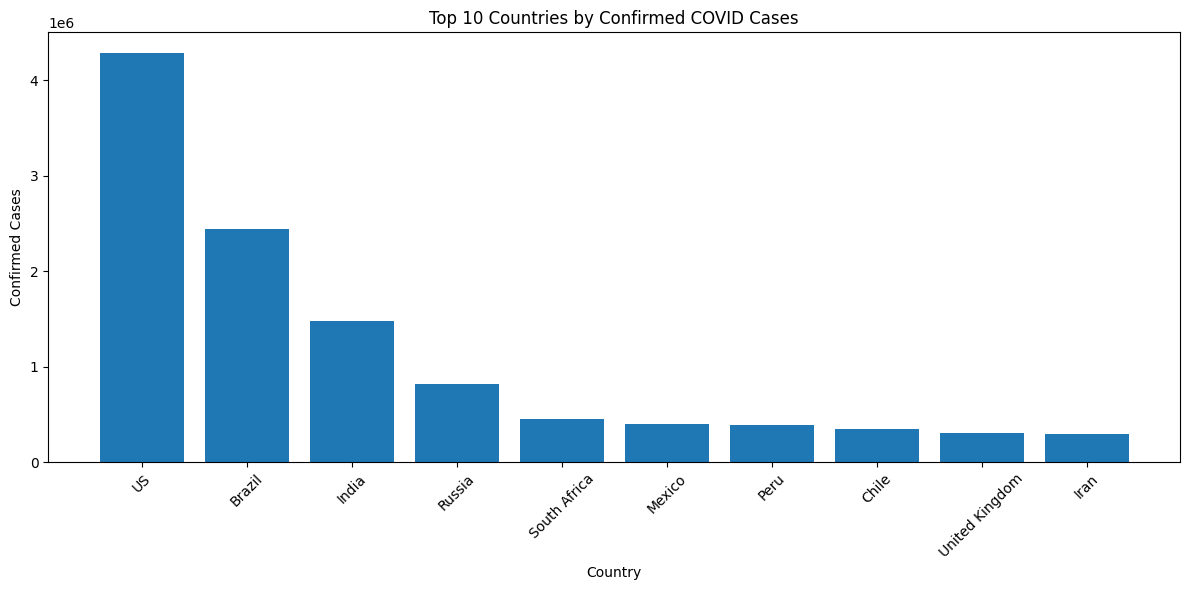

In [23]:
top_10_pd = top_10_confirmed.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_10_pd["Country/Region"],
    top_10_pd["Confirmed"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Confirmed COVID Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.tight_layout()
plt.show()

## Task 6: Top 10 Countries by Death Rate

In [25]:
from pyspark.sql.functions import round
death_rate_df = country_latest_df.withColumn(
    "Death_Rate",
    round(
        (col("Deaths") / col("Confirmed")) * 100,
        2
    )
)

top_death_rate_df = death_rate_df.select(
    "Country/Region",
    "Confirmed",
    "Deaths",
    "Death_Rate"
).orderBy(
    col("Death_Rate").desc()
)

top_10_death_rate = top_death_rate_df.limit(10)
top_10_death_rate.show()

+--------------+---------+------+----------+
|Country/Region|Confirmed|Deaths|Death_Rate|
+--------------+---------+------+----------+
|         Yemen|     1691|   483|     28.56|
|United Kingdom|   301708| 45844|     15.19|
|       Belgium|    66428|  9822|     14.79|
|         Italy|   246286| 35112|     14.26|
|        France|   220352| 30212|     13.71|
|       Hungary|     4448|   596|      13.4|
|   Netherlands|    53413|  6160|     11.53|
|        Mexico|   395489| 44022|     11.13|
|         Spain|   272421| 28432|     10.44|
|Western Sahara|       10|     1|      10.0|
+--------------+---------+------+----------+



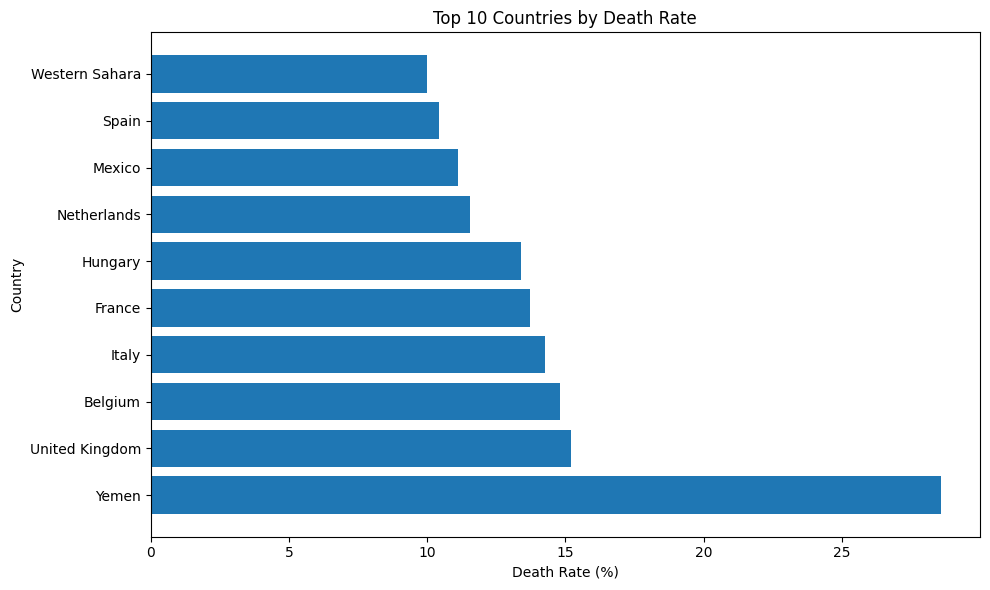

In [26]:
death_rate_pd = top_10_death_rate.toPandas()

plt.figure(figsize=(10,6))

plt.barh(
    death_rate_pd["Country/Region"],
    death_rate_pd["Death_Rate"]
)

plt.title("Top 10 Countries by Death Rate")
plt.xlabel("Death Rate (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## Task 7: WHO Region-wise Total Cases

In [27]:
full_grouped_df.columns

['Date',
 'Country/Region',
 'Confirmed',
 'Deaths',
 'Recovered',
 'Active',
 'New cases',
 'New deaths',
 'New recovered',
 'WHO Region']

In [28]:
from pyspark.sql.functions import sum

region_summary_df = full_grouped_df.groupBy(
    "WHO Region"
).agg(
    sum("Confirmed").alias("Total_Confirmed"),
    sum("Deaths").alias("Total_Deaths"),
    sum("Recovered").alias("Total_Recovered")
)
region_summary_df.show()

+--------------------+---------------+------------+---------------+
|          WHO Region|Total_Confirmed|Total_Deaths|Total_Recovered|
+--------------------+---------------+------------+---------------+
|              Europe|      248879793|    19271040|      123202075|
|     Western Pacific|       26374411|      932430|       18861950|
|              Africa|       21791827|      439978|       11193730|
|Eastern Mediterra...|       74082892|     1924029|       48050703|
|            Americas|      402261194|    19359292|      157069444|
|     South-East Asia|       55118365|     1458134|       30030327|
+--------------------+---------------+------------+---------------+



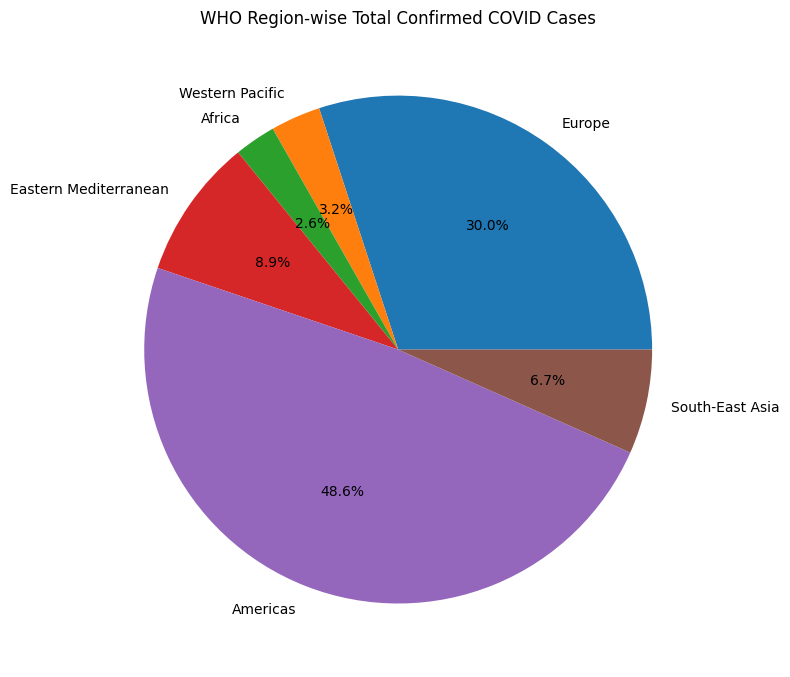

In [30]:
region_pd = region_summary_df.toPandas()

plt.figure(figsize=(8,8))

plt.pie(
    region_pd["Total_Confirmed"],
    labels=region_pd["WHO Region"],
    autopct='%1.1f%%'
)

plt.title("WHO Region-wise Total Confirmed COVID Cases")

plt.tight_layout()
plt.show()

# Module 4: Time-Series Analysis

## Task 8: Daily Global New Cases Trend

In [32]:
day_wise_df.columns
daily_cases_df = day_wise_df.select(
    "Date",
    "New cases"
)
daily_cases_df.show(10)

+----------+---------+
|      Date|New cases|
+----------+---------+
|2020-01-22|        0|
|2020-01-23|       99|
|2020-01-24|      287|
|2020-01-25|      493|
|2020-01-26|      684|
|2020-01-27|      809|
|2020-01-28|     2651|
|2020-01-29|      588|
|2020-01-30|     2068|
|2020-01-31|     1693|
+----------+---------+
only showing top 10 rows


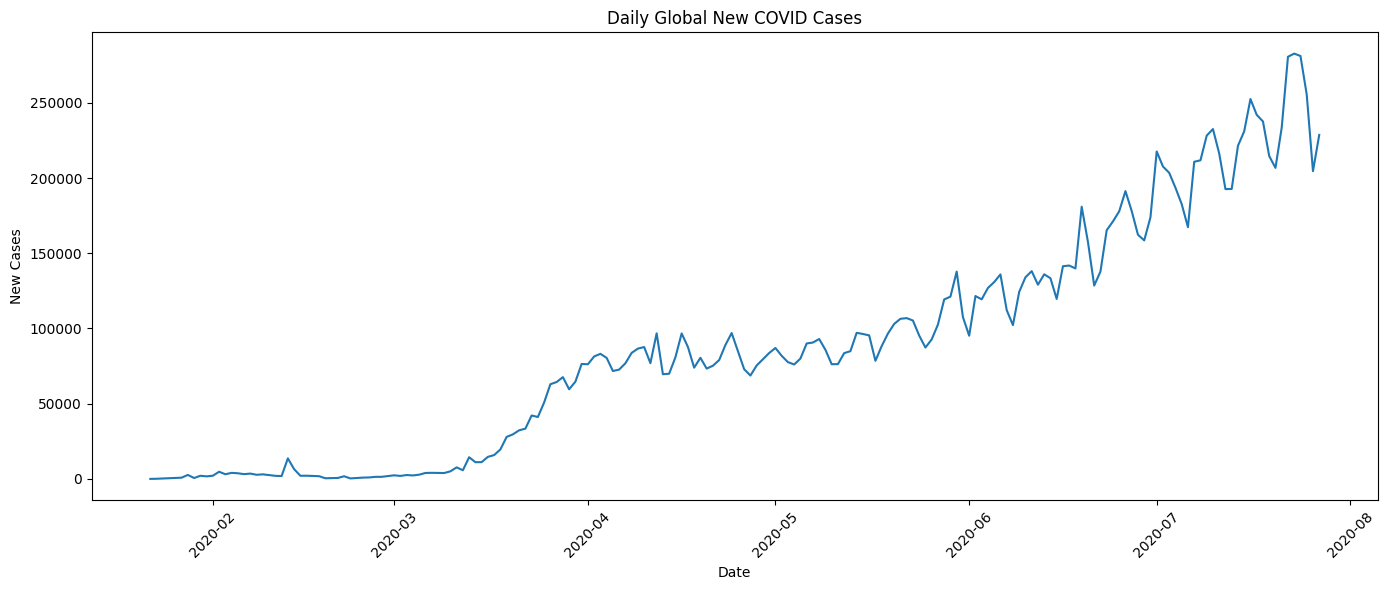

In [ ]:
daily_cases_pd = daily_cases_df.toPandas()
plt.figure(figsize=(14,6))

plt.plot(
    daily_cases_pd["Date"],
    daily_cases_pd["New cases"]
)

plt.xticks(rotation=45)

plt.title("Daily Global New COVID Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.tight_layout()
plt.show()

## Task 9: Daily Global Death Growth Trend

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag

window_spec = Window.orderBy("Date")

death_growth_df = day_wise_df.withColumn(
    "Previous_Day_Deaths",
    lag("New deaths").over(window_spec)
)

death_growth_df = death_growth_df.withColumn(
    "Death_Growth_Percentage",
    when(
        col("Previous_Day_Deaths").isNull(),
        None
    ).when(
        col("Previous_Day_Deaths") == 0,
        0
    ).otherwise(
        round(
            (
                col("New deaths") /
                col("Previous_Day_Deaths")
            ) * 100,
            2
        )
    )
)
death_growth_df.select(
    "Date",
    "New deaths",
    "Previous_Day_Deaths",
    "Death_Growth_Percentage"
).show(10)

+----------+----------+-------------------+-----------------------+
|      Date|New deaths|Previous_Day_Deaths|Death_Growth_Percentage|
+----------+----------+-------------------+-----------------------+
|2020-01-22|         0|               NULL|                   NULL|
|2020-01-23|         1|                  0|                    0.0|
|2020-01-24|         8|                  1|                  800.0|
|2020-01-25|        16|                  8|                  200.0|
|2020-01-26|        14|                 16|                   87.5|
|2020-01-27|        26|                 14|                 185.71|
|2020-01-28|        49|                 26|                 188.46|
|2020-01-29|         2|                 49|                   4.08|
|2020-01-30|        38|                  2|                 1900.0|
|2020-01-31|        42|                 38|                 110.53|
+----------+----------+-------------------+-----------------------+
only showing top 10 rows


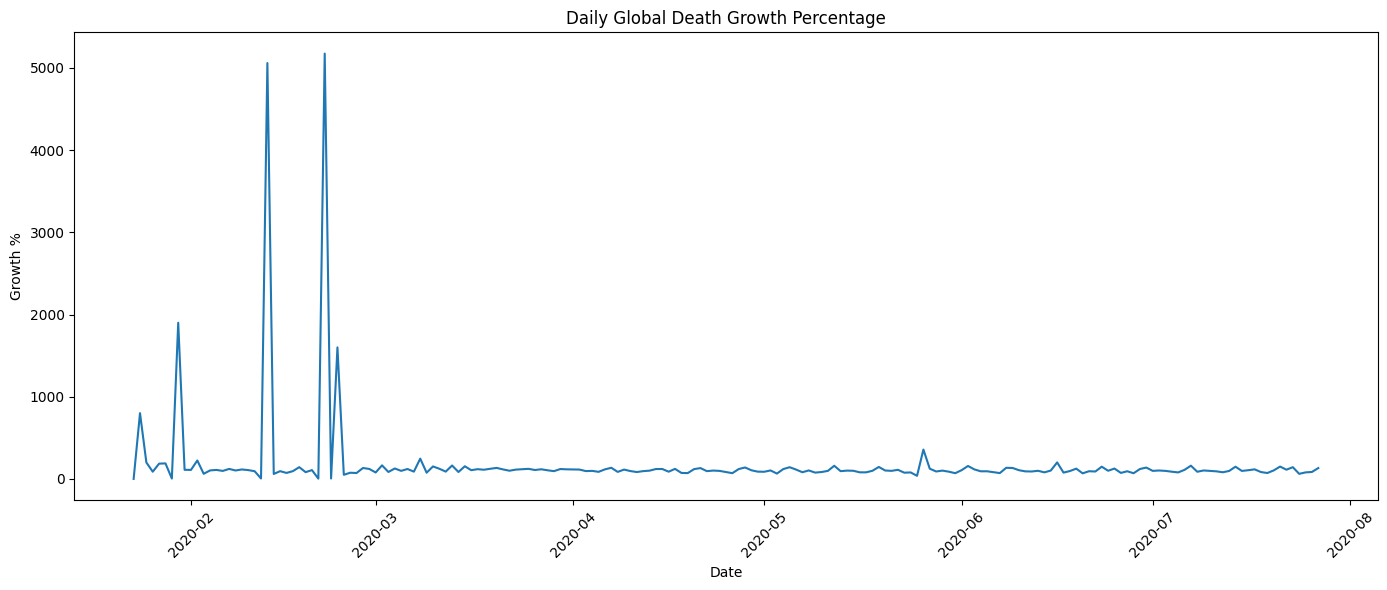

In [39]:
death_growth_pd = death_growth_df.select(
    "Date",
    "Death_Growth_Percentage"
).toPandas()

plt.figure(figsize=(14,6))

plt.plot(
    death_growth_pd["Date"],
    death_growth_pd["Death_Growth_Percentage"]
)

plt.xticks(rotation=45)

plt.title("Daily Global Death Growth Percentage")
plt.xlabel("Date")
plt.ylabel("Growth %")

plt.tight_layout()
plt.show()

## Task 10: Monthly COVID Case Growth


In [36]:
from pyspark.sql.functions import month
monthly_cases_df = full_grouped_df.withColumn(
    "Month",
    month("Date")
)

monthly_summary_df = monthly_cases_df.groupBy(
    "Month"
).agg(
    sum("Confirmed").alias("Total_Confirmed")
).orderBy("Month")

monthly_summary_df.show()

+-----+---------------+
|Month|Total_Confirmed|
+-----+---------------+
|    1|          38534|
|    2|        1663437|
|    3|        9002815|
|    4|       63391662|
|    5|      144990399|
|    6|      246525787|
|    7|      362895848|
+-----+---------------+



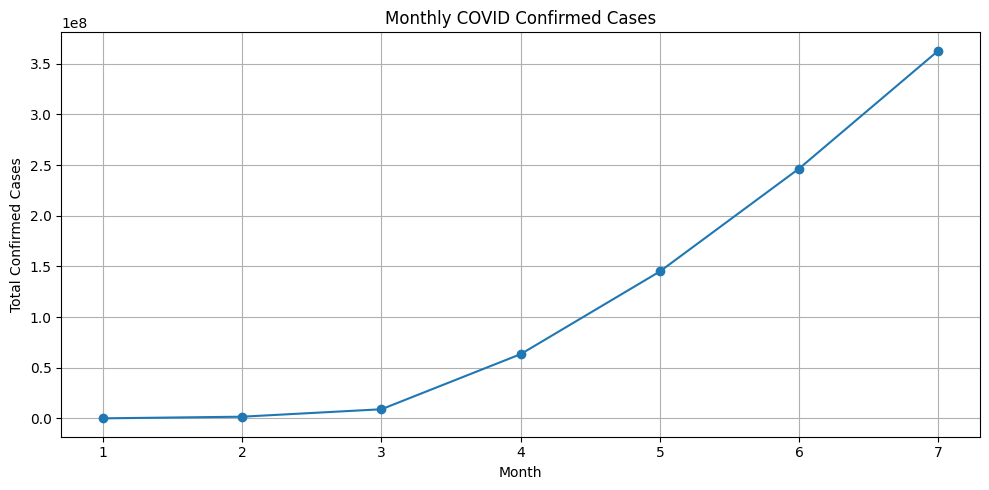

In [37]:
monthly_pd = monthly_summary_df.toPandas()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pd["Month"],
    monthly_pd["Total_Confirmed"],
    marker='o'
)

plt.title("Monthly COVID Confirmed Cases")
plt.xlabel("Month")
plt.ylabel("Total Confirmed Cases")

plt.grid(True)

plt.tight_layout()
plt.show()

# Module 5: Window Function Tasks

## Task 11: Top 5 Most Affected Countries Per WHO Region

In [40]:
from pyspark.sql.functions import dense_rank
region_window = Window.partitionBy(
    "WHO Region"
).orderBy(
    col("Confirmed").desc()
)

ranked_df = country_latest_df.withColumn(
    "Rank",
    dense_rank().over(region_window)
)
top_5_region_df = ranked_df.filter(
    col("Rank") <= 5
)
top_5_region_df.select(
    "WHO Region",
    "Country/Region",
    "Confirmed",
    "Rank"
).orderBy(
    "WHO Region",
    "Rank"
).show(100, truncate=False)

+---------------------+--------------+---------+----+
|WHO Region           |Country/Region|Confirmed|Rank|
+---------------------+--------------+---------+----+
|Africa               |South Africa  |452529   |1   |
|Africa               |Nigeria       |41180    |2   |
|Africa               |Ghana         |33624    |3   |
|Africa               |Algeria       |27973    |4   |
|Africa               |Kenya         |17975    |5   |
|Americas             |US            |4290259  |1   |
|Americas             |Brazil        |2442375  |2   |
|Americas             |Mexico        |395489   |3   |
|Americas             |Peru          |389717   |4   |
|Americas             |Chile         |347923   |5   |
|Eastern Mediterranean|Iran          |293606   |1   |
|Eastern Mediterranean|Pakistan      |274289   |2   |
|Eastern Mediterranean|Saudi Arabia  |268934   |3   |
|Eastern Mediterranean|Iraq          |112585   |4   |
|Eastern Mediterranean|Qatar         |109597   |5   |
|Europe               |Russi

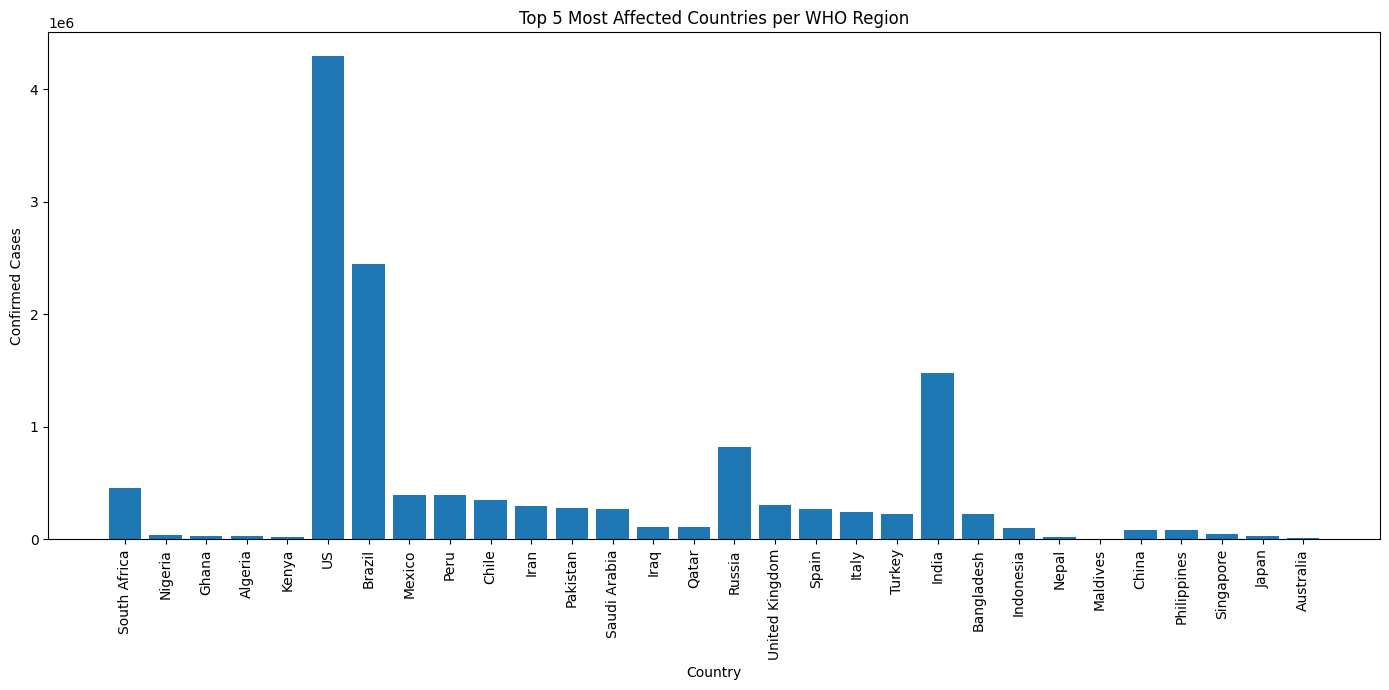

In [41]:
top_5_pd = top_5_region_df.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.bar(
    top_5_pd["Country/Region"],
    top_5_pd["Confirmed"]
)

plt.xticks(rotation=90)

plt.title("Top 5 Most Affected Countries per WHO Region")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.tight_layout()
plt.show()

## Task 12: Country-wise Daily Case Increase

In [42]:
country_window = Window.partitionBy(
    "Country/Region"
).orderBy(
    "Date"
)

daily_increase_df = full_grouped_df.withColumn(
    "Previous_Day_Confirmed",
    lag("Confirmed").over(country_window)
)

daily_increase_df = daily_increase_df.withColumn(
    "Daily_Case_Increase",
    col("Confirmed") - col("Previous_Day_Confirmed")
)

daily_increase_df.select(
    "Country/Region",
    "Date",
    "Confirmed",
    "Previous_Day_Confirmed",
    "Daily_Case_Increase"
).show(20)

+--------------+----------+---------+----------------------+-------------------+
|Country/Region|      Date|Confirmed|Previous_Day_Confirmed|Daily_Case_Increase|
+--------------+----------+---------+----------------------+-------------------+
|   Afghanistan|2020-01-22|        0|                  NULL|               NULL|
|   Afghanistan|2020-01-23|        0|                     0|                  0|
|   Afghanistan|2020-01-24|        0|                     0|                  0|
|   Afghanistan|2020-01-25|        0|                     0|                  0|
|   Afghanistan|2020-01-26|        0|                     0|                  0|
|   Afghanistan|2020-01-27|        0|                     0|                  0|
|   Afghanistan|2020-01-28|        0|                     0|                  0|
|   Afghanistan|2020-01-29|        0|                     0|                  0|
|   Afghanistan|2020-01-30|        0|                     0|                  0|
|   Afghanistan|2020-01-31| 

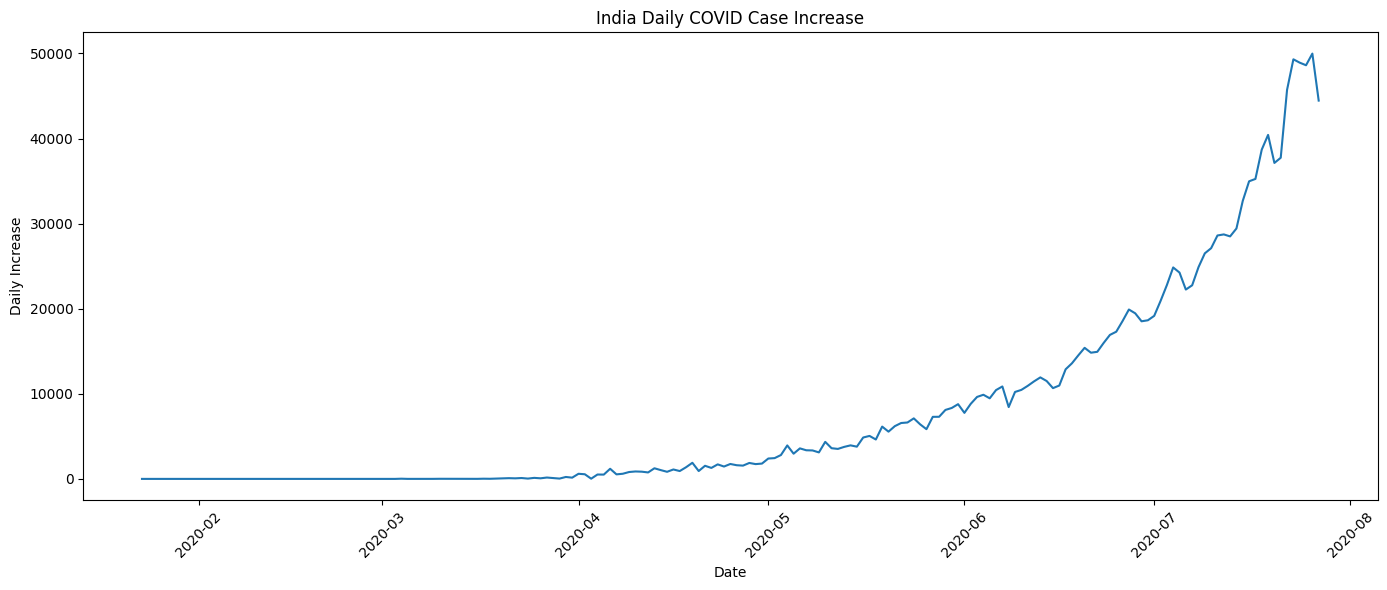

In [44]:
india_df = daily_increase_df.filter(
    col("Country/Region") == "India"
)
india_pd = india_df.select(
    "Date",
    "Daily_Case_Increase"
).toPandas()

plt.figure(figsize=(14,6))

plt.plot(
    india_pd["Date"],
    india_pd["Daily_Case_Increase"]
)

plt.xticks(rotation=45)

plt.title("India Daily COVID Case Increase")
plt.xlabel("Date")
plt.ylabel("Daily Increase")

plt.tight_layout()
plt.show()

# Module 6: Join Operations

## Task 13: Compare Latest Dataset Sources

In [ ]:
from pyspark.sql.functions import col, abs

country_latest_clean = country_latest_df.withColumnRenamed(
    "Country/Region",
    "Country"
)

worldometer_clean = worldometer_df.withColumnRenamed(
    "Country/Region",
    "Country"
)

country_latest_selected = country_latest_clean.select(
    "Country",
    "Confirmed",
    "Deaths",
    "Recovered"
)

worldometer_selected = worldometer_clean.select(
    "Country",
    "TotalCases",
    "TotalDeaths",
    "TotalRecovered"
)

joined_df = country_latest_selected.join(
    worldometer_selected,
    on="Country",
    how="inner"
)

comparison_df = joined_df.withColumn(
    "Confirmed_Difference",
    abs(col("Confirmed") - col("TotalCases"))
).withColumn(
    "Death_Difference",
    abs(col("Deaths") - col("TotalDeaths"))
).withColumn(
    "Recovery_Difference",
    abs(col("Recovered") - col("TotalRecovered"))
)

comparison_df.select(
    "Country",
    "Confirmed_Difference",
    "Death_Difference",
    "Recovery_Difference"
).orderBy(
    col("Confirmed_Difference").desc()
).show(20, truncate=False)

+------------------+--------------------+----------------+-------------------+
|Country           |Confirmed_Difference|Death_Difference|Recovery_Difference|
+------------------+--------------------+----------------+-------------------+
|India             |545336              |8230            |426218             |
|Brazil            |475187              |11026           |201019             |
|Colombia          |100609              |3162            |61194              |
|South Africa      |85655               |2537            |112391             |
|Spain             |82109               |68              |NULL               |
|Mexico            |67201               |6495            |5038               |
|Peru              |65692               |2006            |37790              |
|Argentina         |60779               |1192            |27277              |
|Russia            |55214               |1272            |74108              |
|Philippines       |37420               |205        

In [ ]:
comparison_pd = comparison_df.select(
    "Country",
    "Confirmed_Difference"
).orderBy(
    col("Confirmed_Difference").desc()
).limit(10).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    comparison_pd["Country"],
    comparison_pd["Confirmed_Difference"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Dataset Mismatches in Confirmed Cases")
plt.xlabel("Country")
plt.ylabel("Difference in Confirmed Cases")

plt.tight_layout()
plt.show()

## Task 14: Population vs Total Cases

In [46]:
from pyspark.sql.functions import round

infection_df = worldometer_df.withColumn(
    "Infection_Rate",
    round(
        (
            col("TotalCases") /
            col("Population")
        ) * 100,
        2
    )
)

top_infection_df = infection_df.select(
    "Country/Region",
    "Population",
    "TotalCases",
    "Infection_Rate"
).orderBy(
    col("Infection_Rate").desc()
)

top_infection_df.show(20, truncate=False)

+--------------+----------+----------+--------------+
|Country/Region|Population|TotalCases|Infection_Rate|
+--------------+----------+----------+--------------+
|Qatar         |2807805   |112092    |3.99          |
|French Guiana |299385    |8127      |2.71          |
|Bahrain       |1706669   |42889     |2.51          |
|San Marino    |33938     |699       |2.06          |
|Chile         |19132514  |366671    |1.92          |
|Panama        |4321282   |71418     |1.65          |
|Kuwait        |4276658   |70045     |1.64          |
|Oman          |5118446   |80713     |1.58          |
|USA           |331198130 |5032179   |1.52          |
|Vatican City  |801       |12        |1.5           |
|Peru          |33016319  |455409    |1.38          |
|Brazil        |212710692 |2917562   |1.37          |
|Armenia       |2963811   |39819     |1.34          |
|Andorra       |77278     |944       |1.22          |
|Luxembourg    |626952    |7073      |1.13          |
|Mayotte       |273419    |3

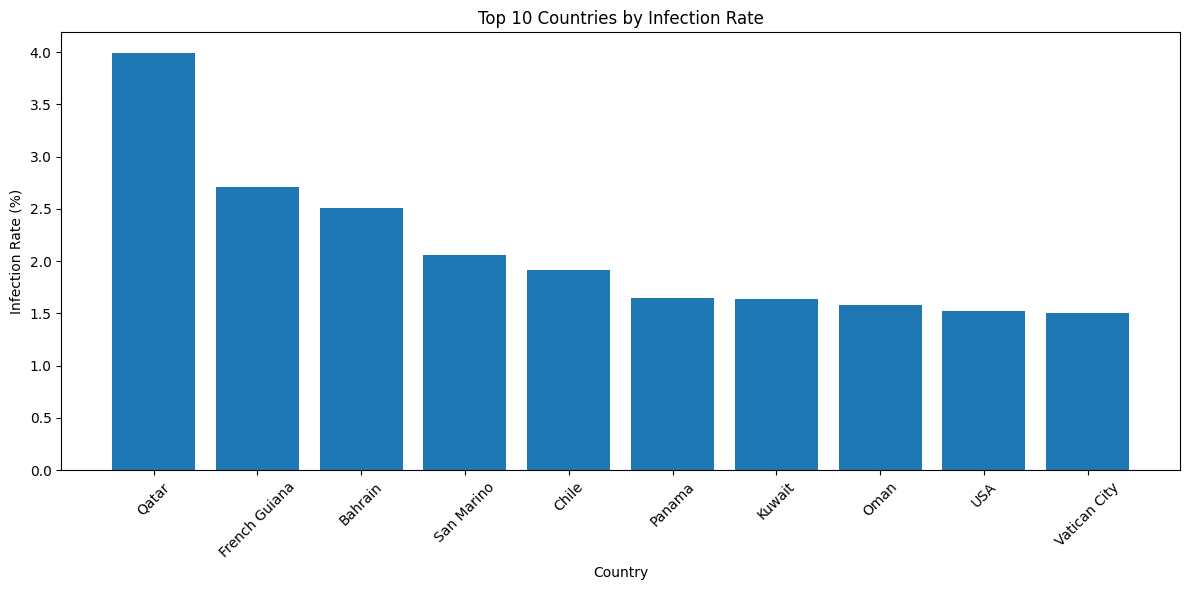

In [47]:
infection_pd = top_infection_df.limit(10).toPandas()

plt.figure(figsize=(12,6))

plt.bar(
    infection_pd["Country/Region"],
    infection_pd["Infection_Rate"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Infection Rate")
plt.xlabel("Country")
plt.ylabel("Infection Rate (%)")

plt.tight_layout()
plt.show()

# Module 7: Geographic Analysis

## Task 15: USA State-wise Case Distribution

In [48]:
from pyspark.sql.functions import count, col

state_distribution_df = usa_county_df.groupBy(
    "Province_State"
).agg(
    count("Admin2").alias("County_Count")
).orderBy(
    col("County_Count").desc()
)

state_distribution_df.show(truncate=False)

+--------------+------------+
|Province_State|County_Count|
+--------------+------------+
|Texas         |48128       |
|Georgia       |30268       |
|Virginia      |25380       |
|Kentucky      |22936       |
|Missouri      |22184       |
|Kansas        |20116       |
|Illinois      |19552       |
|North Carolina|19176       |
|Iowa          |18988       |
|Tennessee     |18236       |
|Nebraska      |17860       |
|Indiana       |17672       |
|Ohio          |16920       |
|Minnesota     |16732       |
|Michigan      |16356       |
|Mississippi   |15792       |
|Puerto Rico   |15040       |
|Oklahoma      |14852       |
|Arkansas      |14476       |
|Wisconsin     |13912       |
+--------------+------------+
only showing top 20 rows


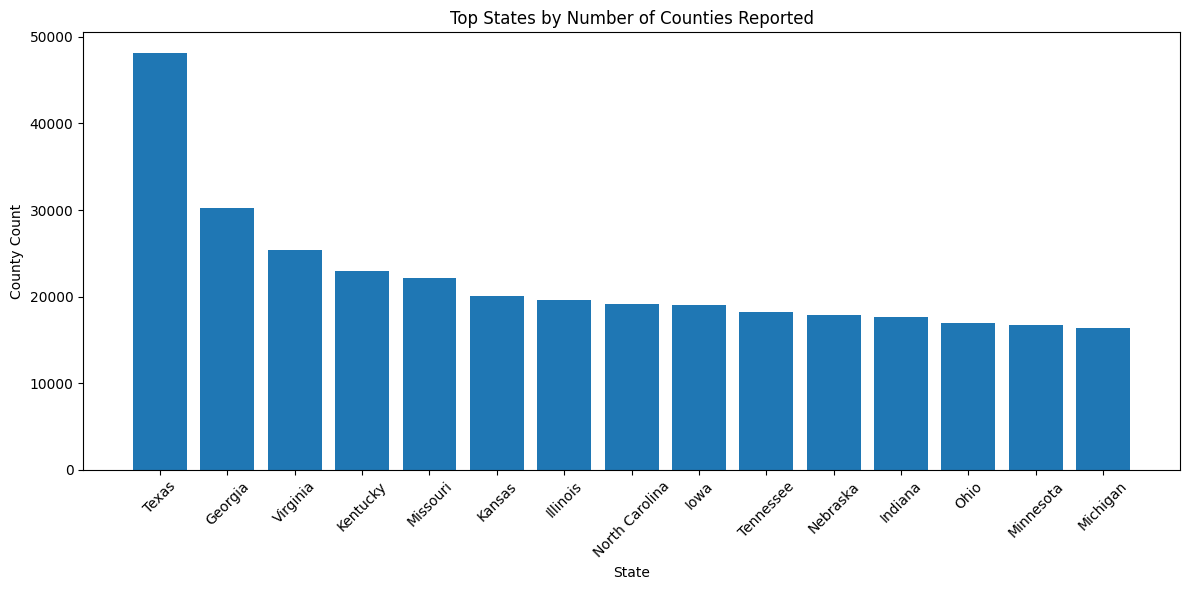

In [49]:
state_pd = state_distribution_df.limit(15).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    state_pd["Province_State"],
    state_pd["County_Count"]
)

plt.xticks(rotation=45)

plt.title("Top States by Number of Counties Reported")
plt.xlabel("State")
plt.ylabel("County Count")

plt.tight_layout()
plt.show()

## Task 16: Latitude-Longitude Based Case Clusters



In [50]:
geo_cluster_df = covid_clean_df.select(
    "Country_Region",
    "Lat",
    "Long",
    "Confirmed"
).filter(
    (col("Lat").isNotNull()) &
    (col("Long").isNotNull())
)

geo_cluster_df.show(truncate=False)

+-------------------+---------+----------+---------+
|Country_Region     |Lat      |Long      |Confirmed|
+-------------------+---------+----------+---------+
|Afghanistan        |33.93911 |67.709953 |0        |
|Albania            |41.1533  |20.1683   |0        |
|Algeria            |28.0339  |1.6596    |0        |
|Andorra            |42.5063  |1.5218    |0        |
|Angola             |-11.2027 |17.8739   |0        |
|Antigua and Barbuda|17.0608  |-61.7964  |0        |
|Argentina          |-38.4161 |-63.6167  |0        |
|Armenia            |40.0691  |45.0382   |0        |
|Australia          |-35.4735 |149.0124  |0        |
|Australia          |-33.8688 |151.2093  |0        |
|Australia          |-12.4634 |130.8456  |0        |
|Australia          |-27.4698 |153.0251  |0        |
|Australia          |-34.9285 |138.6007  |0        |
|Australia          |-42.8821 |147.3272  |0        |
|Australia          |-37.8136 |144.9631  |0        |
|Australia          |-31.9505 |115.8605  |0   

In [ ]:
geo_pd = geo_cluster_df.limit(1000).toPandas()

plt.figure(figsize=(10,6))

plt.scatter(
    geo_pd["Long"],
    geo_pd["Lat"],
    s=geo_pd["Confirmed"] / 1000
)

plt.title("COVID Case Clusters by Latitude and Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

# Module 8: Advanced Analytical Tasks

## Task 17: Recovery Rate Analysis

In [51]:
recovery_df = country_latest_df.withColumn(
    "Recovery_Rate",
    round(
        (
            col("Recovered") /
            col("Confirmed")
        ) * 100,
        2
    )
)

best_recovery_df = recovery_df.select(
    "Country/Region",
    "Confirmed",
    "Recovered",
    "Recovery_Rate"
).orderBy(
    col("Recovery_Rate").desc()
)

worst_recovery_df = recovery_df.select(
    "Country/Region",
    "Confirmed",
    "Recovered",
    "Recovery_Rate"
).orderBy(
    col("Recovery_Rate").asc()
)

best_recovery_df.show(10, truncate=False)
worst_recovery_df.show(10, truncate=False)

+--------------+---------+---------+-------------+
|Country/Region|Confirmed|Recovered|Recovery_Rate|
+--------------+---------+---------+-------------+
|Dominica      |18       |18       |100.0        |
|Grenada       |23       |23       |100.0        |
|Holy See      |12       |12       |100.0        |
|Djibouti      |5059     |4977     |98.38        |
|Iceland       |1854     |1823     |98.33        |
|Brunei        |141      |138      |97.87        |
|New Zealand   |1557     |1514     |97.24        |
|Qatar         |109597   |106328   |97.02        |
|Malaysia      |8904     |8601     |96.6         |
|Mauritius     |344      |332      |96.51        |
+--------------+---------+---------+-------------+
only showing top 10 rows
+--------------+---------+---------+-------------+
|Country/Region|Confirmed|Recovered|Recovery_Rate|
+--------------+---------+---------+-------------+
|Canada        |116458   |0        |0.0          |
|Mozambique    |1701     |0        |0.0          |
|Serbi

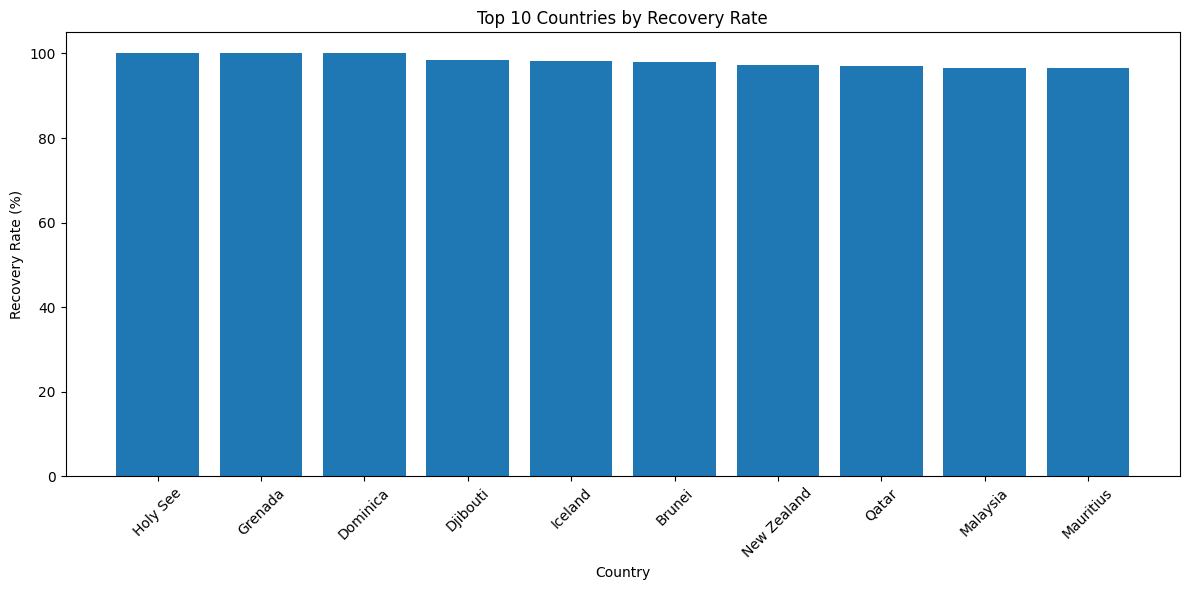

In [ ]:
best_recovery_pd = best_recovery_df.limit(10).toPandas()
plt.figure(figsize=(12,6))

plt.bar(
    best_recovery_pd["Country/Region"],
    best_recovery_pd["Recovery_Rate"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Recovery Rate")
plt.xlabel("Country")
plt.ylabel("Recovery Rate (%)")

plt.tight_layout()
plt.show()

## Task 18: Active Case Burden Analysis

In [54]:
active_burden_df = country_latest_df.filter(
    col("Active") > col("Recovered")
)

active_burden_df.select(
    "Country/Region",
    "Active",
    "Recovered"
).orderBy(
    col("Active").desc()
).show(truncate=False)

+------------------+-------+---------+
|Country/Region    |Active |Recovered|
+------------------+-------+---------+
|US                |2816444|1325804  |
|United Kingdom    |254427 |1437     |
|France            |108928 |81212    |
|Canada            |107514 |0        |
|Argentina         |91782  |72575    |
|Sweden            |73695  |0        |
|Philippines       |53649  |26446    |
|Egypt             |52992  |34838    |
|Netherlands       |47064  |189      |
|Bolivia           |47056  |21478    |
|Ecuador           |40733  |34896    |
|Belgium           |39154  |17452    |
|Israel            |36378  |27133    |
|Honduras          |33536  |5039     |
|Dominican Republic|32869  |30204    |
|Serbia            |23598  |0        |
|Nigeria           |22117  |18203    |
|Costa Rica        |11902  |3824     |
|Kenya             |9857   |7833     |
|Ethiopia          |7933   |6386     |
+------------------+-------+---------+
only showing top 20 rows


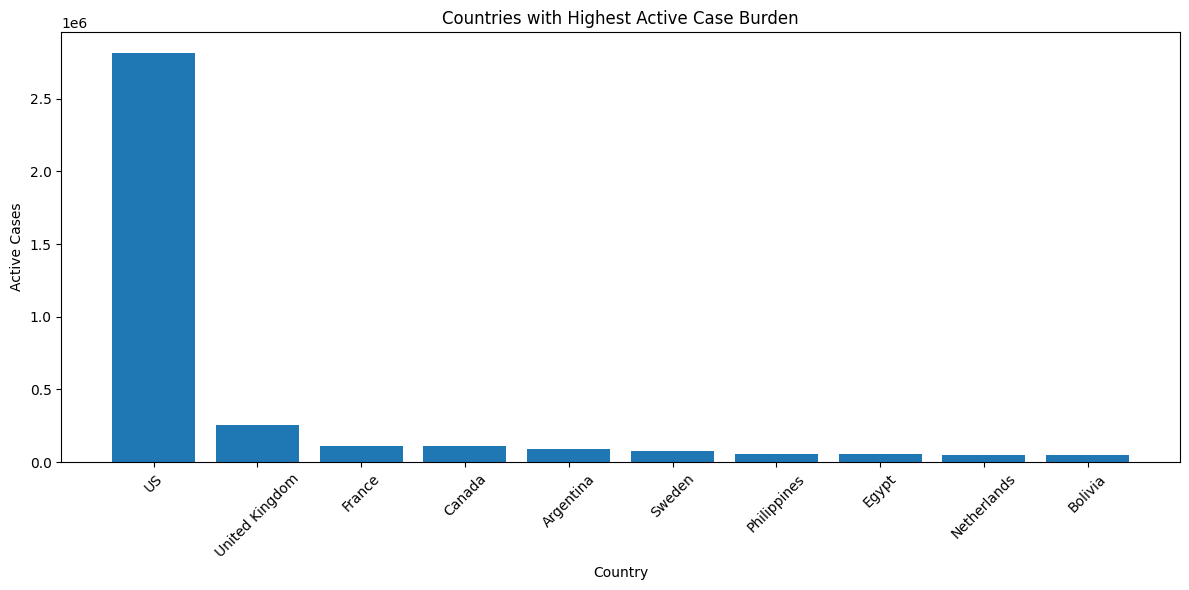

In [55]:
active_burden_pd = active_burden_df.select(
    "Country/Region",
    "Active"
).orderBy(
    col("Active").desc()
).limit(10).toPandas()

plt.figure(figsize=(12,6))

plt.bar(
    active_burden_pd["Country/Region"],
    active_burden_pd["Active"]
)

plt.xticks(rotation=45)

plt.title("Countries with Highest Active Case Burden")
plt.xlabel("Country")
plt.ylabel("Active Cases")

plt.tight_layout()
plt.show()

## Task 19: Identify Pandemic Peaks


In [56]:
max_cases_df = day_wise_df.orderBy(
    col("New cases").desc()
).limit(1)

max_deaths_df = day_wise_df.orderBy(
    col("New deaths").desc()
).limit(1)

max_cases_df.show(truncate=False)
max_deaths_df.show(truncate=False)

+----------+---------+------+---------+-------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|Date      |Confirmed|Deaths|Recovered|Active |New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|No. of countries|
+----------+---------+------+---------+-------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|2020-07-23|15510481 |633506|8710969  |6166006|282756   |9966      |169714       |4.08              |56.16                |7.27                  |187             |
+----------+---------+------+---------+-------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+

+----------+---------+------+---------+-------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|Date      |Con

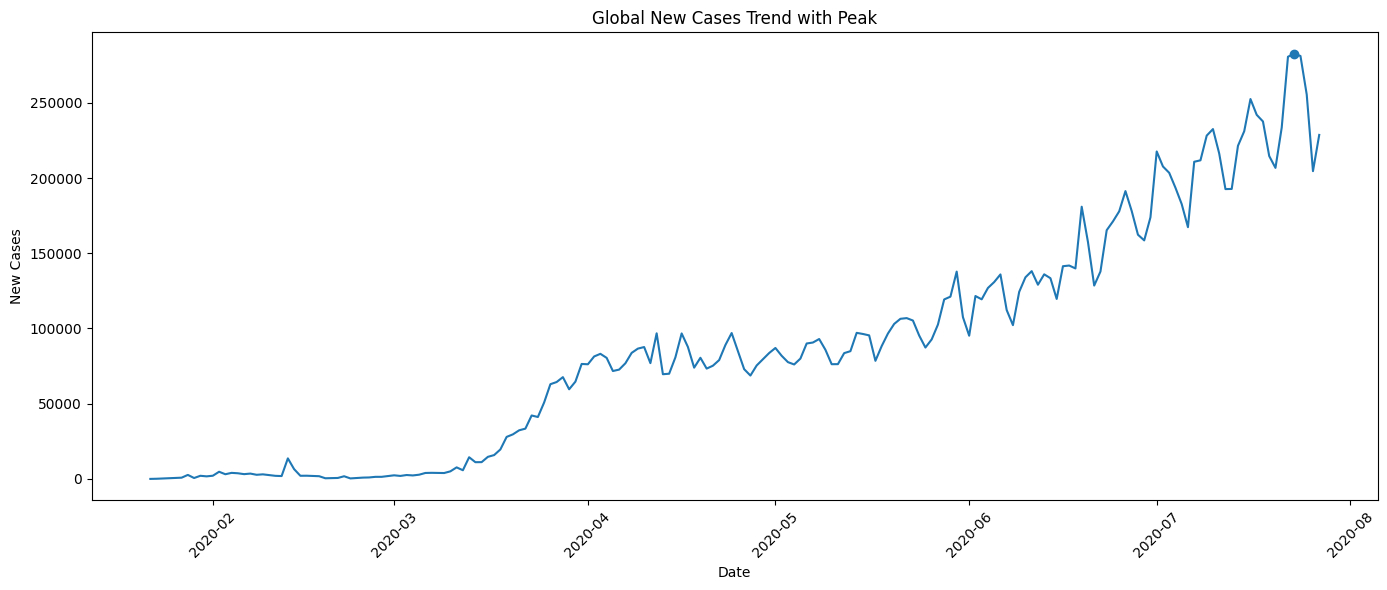

In [57]:
peak_cases_pd = day_wise_df.select(
    "Date",
    "New cases"
).toPandas()

peak_deaths_pd = day_wise_df.select(
    "Date",
    "New deaths"
).toPandas()

plt.figure(figsize=(14,6))

plt.plot(
    peak_cases_pd["Date"],
    peak_cases_pd["New cases"]
)

max_case_index = peak_cases_pd["New cases"].idxmax()

plt.scatter(
    peak_cases_pd["Date"][max_case_index],
    peak_cases_pd["New cases"][max_case_index]
)

plt.xticks(rotation=45)

plt.title("Global New Cases Trend with Peak")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.tight_layout()
plt.show()

# Module 9: Feature Engineering

## Task 20: Create Severity Category

In [59]:
from pyspark.sql.functions import when, col

severity_df = country_latest_df.withColumn(
    "Severity_Category",
    when(col("Confirmed") < 10000, "Low")
    .when(
        (col("Confirmed") >= 10000) &
        (col("Confirmed") < 100000),
        "Medium"
    )
    .when(
        (col("Confirmed") >= 100000) &
        (col("Confirmed") < 1000000),
        "High"
    )
    .otherwise("Critical")
)

severity_df.select(
    "Country/Region",
    "Confirmed",
    "Severity_Category"
).show(truncate=False)

+-------------------+---------+-----------------+
|Country/Region     |Confirmed|Severity_Category|
+-------------------+---------+-----------------+
|Afghanistan        |36263    |Medium           |
|Albania            |4880     |Low              |
|Algeria            |27973    |Medium           |
|Andorra            |907      |Low              |
|Angola             |950      |Low              |
|Antigua and Barbuda|86       |Low              |
|Argentina          |167416   |High             |
|Armenia            |37390    |Medium           |
|Australia          |15303    |Medium           |
|Austria            |20558    |Medium           |
|Azerbaijan         |30446    |Medium           |
|Bahamas            |382      |Low              |
|Bahrain            |39482    |Medium           |
|Bangladesh         |226225   |High             |
|Barbados           |110      |Low              |
|Belarus            |67251    |Medium           |
|Belgium            |66428    |Medium           |


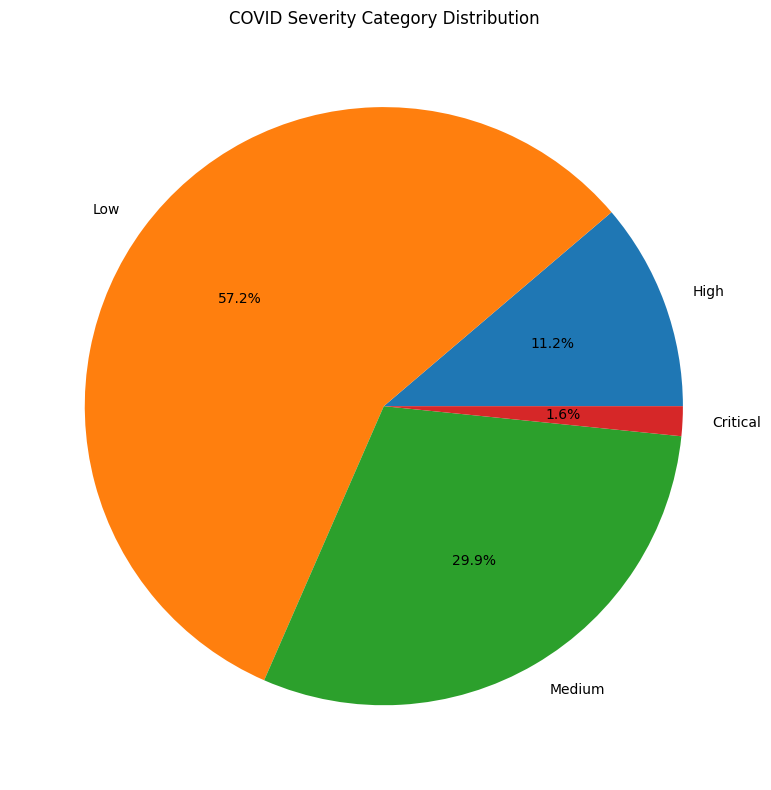

In [61]:
severity_count_df = severity_df.groupBy(
    "Severity_Category"
).count()

severity_pd = severity_count_df.toPandas()

plt.figure(figsize=(8,8))

plt.pie(
    severity_pd["count"],
    labels=severity_pd["Severity_Category"],
    autopct='%1.1f%%'
)

plt.title("COVID Severity Category Distribution")

plt.tight_layout()
plt.show()

# Module 10: Final Mini Pipeline Project

## Task 21: Build COVID Analytics Pipeline

### 1. Extract All Datasets

In [62]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("COVID Analytics Pipeline") \
    .getOrCreate()

full_grouped_df = spark.read.csv(
    "data/full_grouped.csv",
    header=True,
    inferSchema=True
)

covid_clean_df = spark.read.csv(
    "data/covid_19_clean_complete.csv",
    header=True,
    inferSchema=True
)

country_latest_df = spark.read.csv(
    "data/country_wise_latest.csv",
    header=True,
    inferSchema=True
)

day_wise_df = spark.read.csv(
    "data/day_wise.csv",
    header=True,
    inferSchema=True
)

usa_county_df = spark.read.csv(
    "data/usa_county_wise.csv",
    header=True,
    inferSchema=True
)

worldometer_df = spark.read.csv(
    "data/worldometer_data.csv",
    header=True,
    inferSchema=True
)

### 2. Clean Missing Values

In [63]:
from pyspark.sql.functions import col

covid_clean_df = covid_clean_df \
    .withColumnRenamed("Province/State", "Province_State") \
    .withColumnRenamed("Country/Region", "Country_Region")

covid_clean_df = covid_clean_df.fillna({
    "Province_State": "Unknown"
})

### 3. Standardize Country Names

In [64]:
from pyspark.sql.functions import when

full_grouped_df = full_grouped_df.withColumn(
    "Country/Region",
    when(col("Country/Region") == "US", "USA")
    .when(col("Country/Region") == "Korea, South", "South Korea")
    .otherwise(col("Country/Region"))
)

country_latest_df = country_latest_df.withColumn(
    "Country/Region",
    when(col("Country/Region") == "US", "USA")
    .when(col("Country/Region") == "Korea, South", "South Korea")
    .otherwise(col("Country/Region"))
)

worldometer_df = worldometer_df.withColumn(
    "Country/Region",
    when(col("Country/Region") == "US", "USA")
    .when(col("Country/Region") == "Korea, South", "South Korea")
    .otherwise(col("Country/Region"))
)

### 4. Generate Top Countries Table

In [65]:
from pyspark.sql.functions import desc

top_countries_df = country_latest_df.select(
    "Country/Region",
    "Confirmed",
    "Deaths",
    "Recovered"
).orderBy(
    desc("Confirmed")
)

top_countries_df.show(10, truncate=False)

+--------------+---------+------+---------+
|Country/Region|Confirmed|Deaths|Recovered|
+--------------+---------+------+---------+
|USA           |4290259  |148011|1325804  |
|Brazil        |2442375  |87618 |1846641  |
|India         |1480073  |33408 |951166   |
|Russia        |816680   |13334 |602249   |
|South Africa  |452529   |7067  |274925   |
|Mexico        |395489   |44022 |303810   |
|Peru          |389717   |18418 |272547   |
|Chile         |347923   |9187  |319954   |
|United Kingdom|301708   |45844 |1437     |
|Iran          |293606   |15912 |255144   |
+--------------+---------+------+---------+
only showing top 10 rows


### 5. Generate Region Summary

In [66]:
from pyspark.sql.functions import sum

region_summary_df = full_grouped_df.groupBy(
    "WHO Region"
).agg(
    sum("Confirmed").alias("Total_Confirmed"),
    sum("Deaths").alias("Total_Deaths"),
    sum("Recovered").alias("Total_Recovered")
)

region_summary_df.show(truncate=False)

+---------------------+---------------+------------+---------------+
|WHO Region           |Total_Confirmed|Total_Deaths|Total_Recovered|
+---------------------+---------------+------------+---------------+
|Europe               |248879793      |19271040    |123202075      |
|Western Pacific      |26374411       |932430      |18861950       |
|Africa               |21791827       |439978      |11193730       |
|Eastern Mediterranean|74082892       |1924029     |48050703       |
|Americas             |402261194      |19359292    |157069444      |
|South-East Asia      |55118365       |1458134     |30030327       |
+---------------------+---------------+------------+---------------+



### 6. Generate Daily Trends

In [67]:
daily_trend_df = day_wise_df.select(
    "Date",
    "New cases",
    "New deaths",
    "New recovered"
)

daily_trend_df.show(truncate=False)

+----------+---------+----------+-------------+
|Date      |New cases|New deaths|New recovered|
+----------+---------+----------+-------------+
|2020-01-22|0        |0         |0            |
|2020-01-23|99       |1         |2            |
|2020-01-24|287      |8         |6            |
|2020-01-25|493      |16        |3            |
|2020-01-26|684      |14        |13           |
|2020-01-27|809      |26        |9            |
|2020-01-28|2651     |49        |46           |
|2020-01-29|588      |2         |18           |
|2020-01-30|2068     |38        |16           |
|2020-01-31|1693     |42        |78           |
|2020-02-01|2111     |46        |62           |
|2020-02-02|4749     |103       |178          |
|2020-02-03|3100     |64        |145          |
|2020-02-04|4011     |66        |217          |
|2020-02-05|3745     |72        |250          |
|2020-02-06|3159     |70        |347          |
|2020-02-07|3532     |85        |485          |
|2020-02-08|2734     |87        |567    

### 7. Generate Mortality Report

In [68]:
from pyspark.sql.functions import round

mortality_df = country_latest_df.withColumn(
    "Death_Rate",
    round(
        (
            col("Deaths") /
            col("Confirmed")
        ) * 100,
        2
    )
)

mortality_df.select(
    "Country/Region",
    "Confirmed",
    "Deaths",
    "Death_Rate"
).show(truncate=False)

+-------------------+---------+------+----------+
|Country/Region     |Confirmed|Deaths|Death_Rate|
+-------------------+---------+------+----------+
|Afghanistan        |36263    |1269  |3.5       |
|Albania            |4880     |144   |2.95      |
|Algeria            |27973    |1163  |4.16      |
|Andorra            |907      |52    |5.73      |
|Angola             |950      |41    |4.32      |
|Antigua and Barbuda|86       |3     |3.49      |
|Argentina          |167416   |3059  |1.83      |
|Armenia            |37390    |711   |1.9       |
|Australia          |15303    |167   |1.09      |
|Austria            |20558    |713   |3.47      |
|Azerbaijan         |30446    |423   |1.39      |
|Bahamas            |382      |11    |2.88      |
|Bahrain            |39482    |141   |0.36      |
|Bangladesh         |226225   |2965  |1.31      |
|Barbados           |110      |7     |6.36      |
|Belarus            |67251    |538   |0.8       |
|Belgium            |66428    |9822  |14.79     |


### 8. Generate Recovery Report

In [69]:
recovery_df = country_latest_df.withColumn(
    "Recovery_Rate",
    round(
        (
            col("Recovered") /
            col("Confirmed")
        ) * 100,
        2
    )
)

recovery_df.select(
    "Country/Region",
    "Recovered",
    "Recovery_Rate"
).show(truncate=False)

+-------------------+---------+-------------+
|Country/Region     |Recovered|Recovery_Rate|
+-------------------+---------+-------------+
|Afghanistan        |25198    |69.49        |
|Albania            |2745     |56.25        |
|Algeria            |18837    |67.34        |
|Andorra            |803      |88.53        |
|Angola             |242      |25.47        |
|Antigua and Barbuda|65       |75.58        |
|Argentina          |72575    |43.35        |
|Armenia            |26665    |71.32        |
|Australia          |9311     |60.84        |
|Austria            |18246    |88.75        |
|Azerbaijan         |23242    |76.34        |
|Bahamas            |91       |23.82        |
|Bahrain            |36110    |91.46        |
|Bangladesh         |125683   |55.56        |
|Barbados           |94       |85.45        |
|Belarus            |60492    |89.95        |
|Belgium            |17452    |26.27        |
|Belize             |26       |54.17        |
|Benin              |1036     |58.

### 9. Join Datasets

In [70]:
country_latest_clean = country_latest_df.withColumnRenamed(
    "Country/Region",
    "Country"
)

worldometer_clean = worldometer_df.withColumnRenamed(
    "Country/Region",
    "Country"
)

joined_df = country_latest_clean.join(
    worldometer_clean,
    on="Country",
    how="inner"
)

joined_df.show(truncate=False)

+------------+---------+------+---------+-------+---------+----------+-------------+------------------+---------------------+----------------------+-------------------+-------------+-----------------+---------------------+-------------+----------+----------+--------+-----------+---------+--------------+------------+-----------+----------------+----------------+-------------+----------+------------+--------------------+
|Country     |Confirmed|Deaths|Recovered|Active |New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|Confirmed last week|1 week change|1 week % increase|WHO Region           |Continent    |Population|TotalCases|NewCases|TotalDeaths|NewDeaths|TotalRecovered|NewRecovered|ActiveCases|Serious,Critical|Tot Cases/1M pop|Deaths/1M pop|TotalTests|Tests/1M pop|WHO Region          |
+------------+---------+------+---------+-------+---------+----------+-------------+------------------+---------------------+----------------------+------

### 10. Export Outputs as CSV

In [75]:
top_countries_df.toPandas().to_csv("output/top_countries.csv", index=False)
region_summary_df.toPandas().to_csv("output/region_summary.csv", index=False)
daily_trend_df.toPandas().to_csv("output/daily_trends.csv", index=False)
mortality_df.toPandas().to_csv("output/mortality_report.csv", index=False)
recovery_df.toPandas().to_csv("output/recovery_report.csv", index=False)